<a href="https://colab.research.google.com/github/kunal13-Ai/Practice_of_ML/blob/main/California_houses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Price'] = california.target


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.sample(7)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
5789,2.2621,32.0,3.263033,1.052133,768.0,1.819905,34.15,-118.25,1.875
7000,3.3214,42.0,4.454829,1.052960,1269.0,3.953271,33.96,-118.04,1.488
7099,5.0923,16.0,7.176351,1.204054,3836.0,2.591892,33.91,-117.98,2.572
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
13960,3.5288,16.0,12.368852,2.143443,556.0,2.278689,34.25,-116.90,1.897
4578,2.3636,32.0,3.633947,1.096115,1684.0,3.443763,34.07,-118.28,1.900
5489,6.0672,26.0,5.172507,1.091644,953.0,2.568733,33.99,-118.45,4.208


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.corr()['Price']

,Price
MedInc,0.688075
HouseAge,0.105623
AveRooms,0.151948
AveBedrms,-0.046701
Population,-0.024650
AveOccup,-0.023737
Latitude,-0.144160
Longitude,-0.045967
Price,1.000000


In [ ]:
# no duplicate values
df.duplicated().sum()


np.int64(0)

In [ ]:
df.sample(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
16553,5.1047,9.0,6.528042,1.014815,3378.0,3.574603,37.82,-121.24,1.579
11032,4.2500,24.0,5.353436,1.103787,1656.0,2.322581,33.78,-117.84,2.480


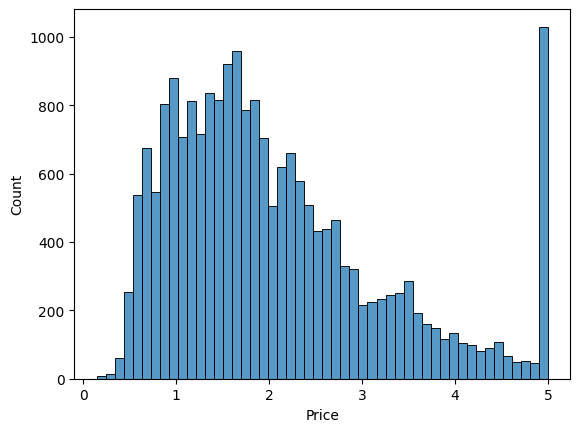

In [ ]:
fig = sns.histplot(data=df, x='Price', bins=50)

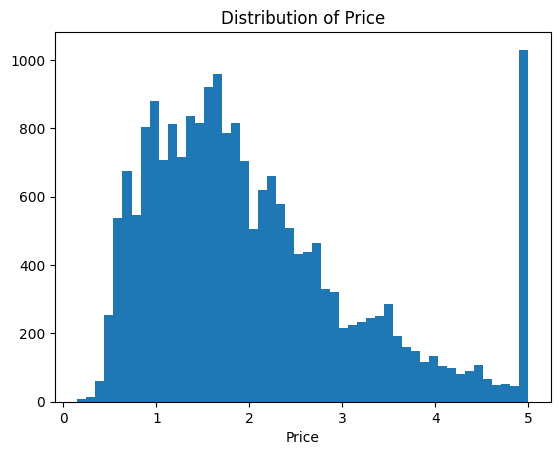

In [ ]:
plt.hist(df['Price'], bins=50)
plt.xlabel('Price')
#plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()
# Distribution is right skewed

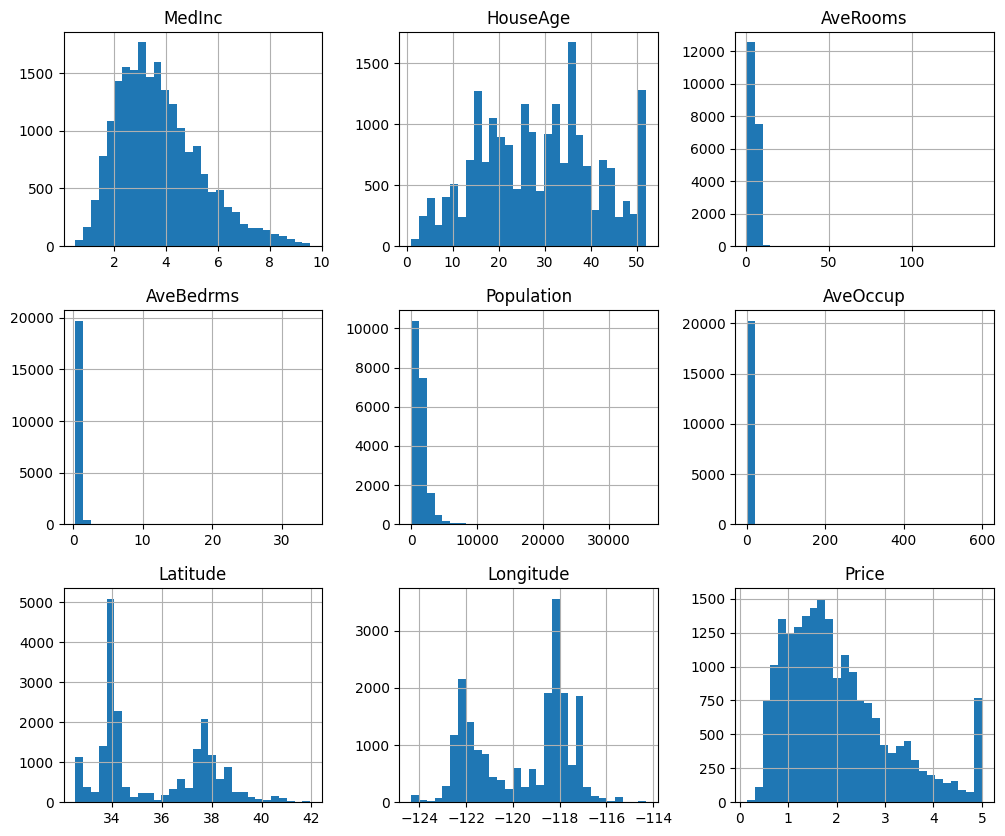

In [ ]:
new_df.hist(figsize=(12,10), bins=30)
plt.show()

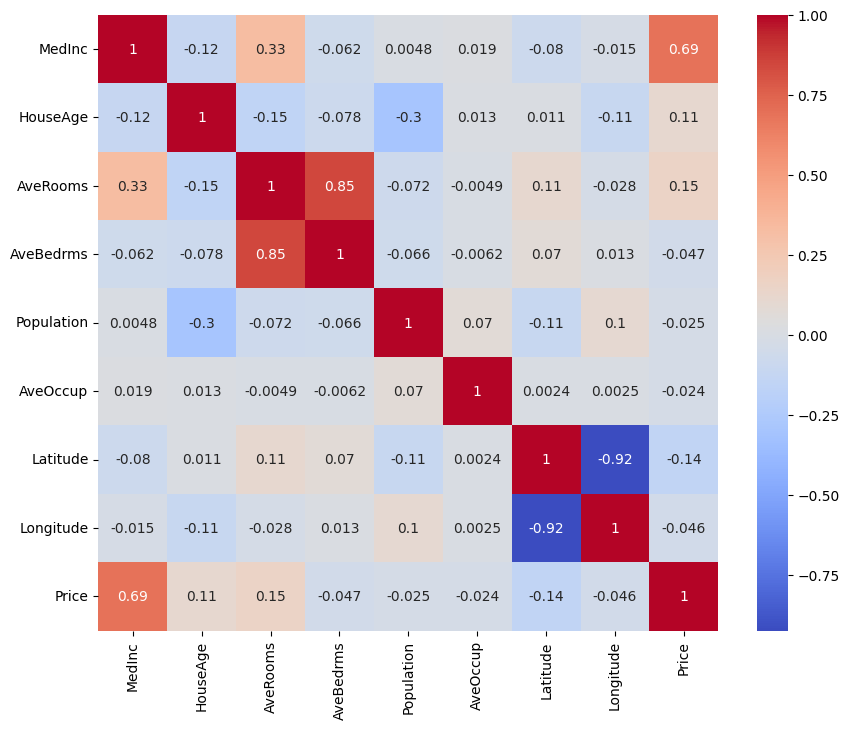

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
x = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
X_train.shape, X_test.shape


((16512, 8), (4128, 8))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [ ]:
type(X_train_scaled)

numpy.ndarray

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled = pd.DataFrame(X_test_scaled)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error,median_absolute_error

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled,Y_train)
y_pred = model.predict(X_test_scaled)


In [ ]:
RMSE = np.sqrt(mean_squared_error(y_pred,Y_test))
MAE = mean_squared_error(y_pred,Y_test)
R2_score = r2_score(y_pred,Y_test)


In [ ]:
print('RMSE:', RMSE)
print('MAE:', MAE)
print('R2_score:', R2_score)

RMSE: 0.7273129773603114
MAE: 0.5289841670367208
R2_score: 0.32137558499095453


In [ ]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(Y_true, y_pred)



In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)

y_pred_rf = rf.predict(X_test)

print("RMSE:", mean_squared_error(Y_test, y_pred_rf))
print("R2:", r2_score(Y_test, y_pred_rf))

RMSE: 0.26220768744907885
R2: 0.7989135306875962


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)
print('Cross-validation RMSE scores:', rmse_scores)
print('Mean RMSE:', rmse_scores.mean())
print('R2_score', r2_score(y_pred,Y_test))


Cross-validation RMSE scores: [0.733323   0.72542822 0.74260039 0.7242896  0.70768761]
Mean RMSE: 0.7266657633193194
R2_score 0.32137558499095453


<Axes: ylabel='MedInc'>

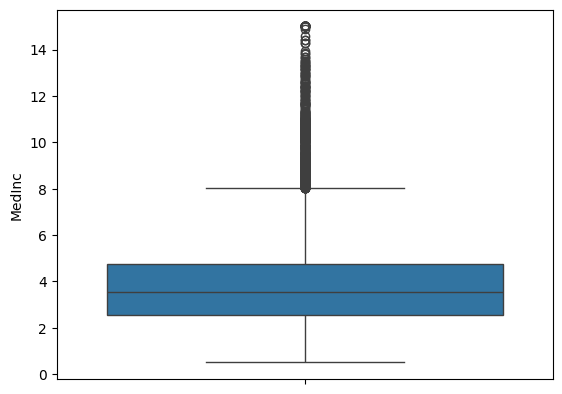

In [ ]:
sns.boxplot(df['MedInc'])

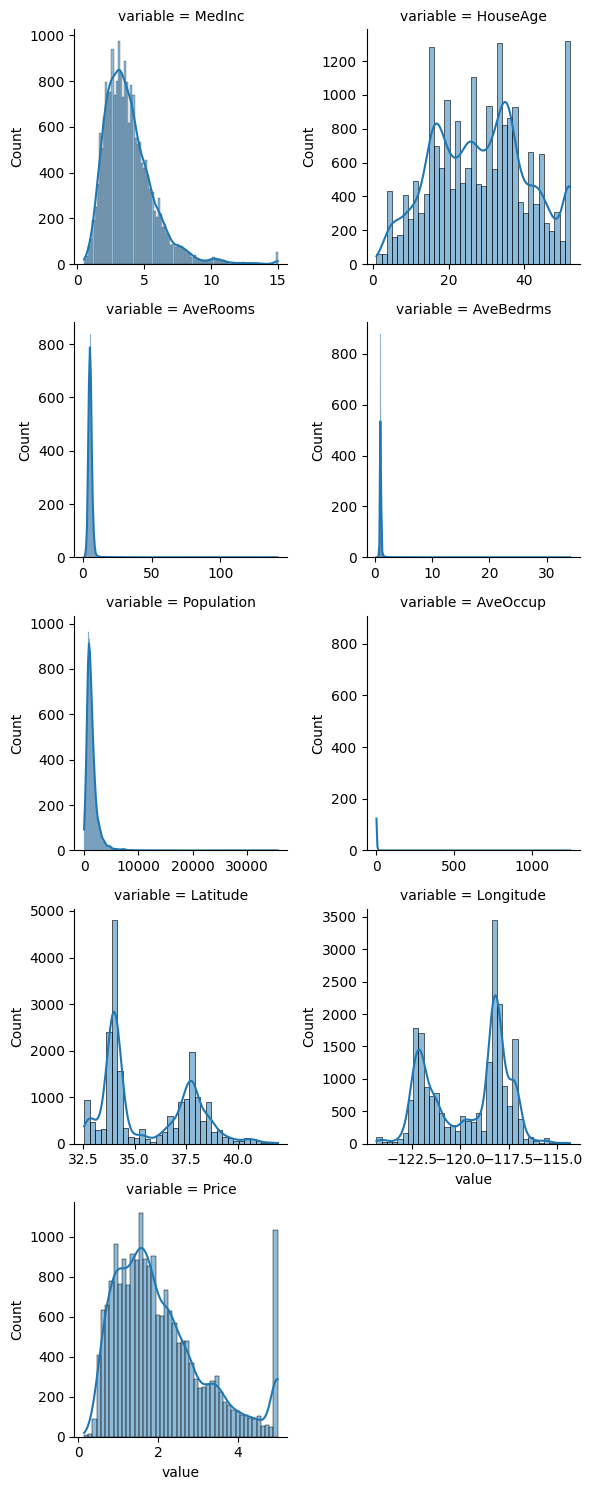

In [ ]:
df_melted = df.select_dtypes(include=['number']).melt()


g = sns.FacetGrid(df_melted, col="variable", col_wrap=2, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)


In [ ]:
df['MedInc'].describe()

,MedInc
count,20640.000000
mean,3.870671
std,1.899822
min,0.499900
25%,2.563400
50%,3.534800
75%,4.743250
max,15.000100


In [ ]:
print('Highest',df['MedInc'].mean() + 3*df['MedInc'].std())
print('lowest',df['MedInc'].mean() - 3*df['MedInc'].std())


Highest 9.570136156742796
lowest -1.828794150928843


In [ ]:
df[(df['MedInc']>9.57) | (df['MedInc']<-1.82 )]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
409,10.0825,52.0,8.209016,1.024590,658.0,2.696721,37.90,-122.28,3.97000
510,11.8603,39.0,7.911111,0.984127,808.0,2.565079,37.82,-122.22,5.00001
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23,5.00001
...,...,...,...,...,...,...,...,...,...
20376,10.2614,16.0,6.421277,0.919149,578.0,2.459574,34.16,-118.86,4.10800
20380,10.1597,16.0,7.606936,1.121387,450.0,2.601156,34.14,-118.83,5.00001
20389,10.0595,26.0,8.692308,1.076923,573.0,3.148352,34.19,-118.90,5.00001
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001


In [ ]:
new_df = df[(df['MedInc'] < 9.57) & (df['MedInc'] > -1.82 )]
new_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
df.shape , new_df.shape

((20640, 9), (20295, 9))

In [ ]:
x = new_df.drop('Price', axis=1)
y = new_df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x ,y , test_size=0.2 , random_state=42)

In [ ]:
x_train.shape , x_test.shape

((16236, 8), (4059, 8))

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)
Y_predict = model.predict(x_test_scaled)

In [ ]:
RMSE = np.sqrt(mean_squared_error(y_pred,Y_test))
MAE = mean_squared_error(y_pred,Y_test)
R2_score = r2_score(y_pred,Y_test)


In [ ]:
print('RMSE:',RMSE)
print('MAE:',MAE)
print('R2_score:',R2_score)

RMSE: 0.7273129773603114
MAE: 0.5289841670367208
R2_score: 0.32137558499095453
